In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("All imports successful")

All imports successful


In [18]:
df = pd.read_csv('../data/customer_complaints_sentiment.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (1750, 4)

Columns: ['Consumer_complaint', 'Product', 'Sentiment', 'Priority']

First 3 rows:


,Consumer_complaint,Product,Sentiment,Priority
0,I had overdraft protection with Regions Bank i...,Checking or savings account or service,0,1
1,"I am the sole, legal representative of my dece...",Checking or savings account or service,0,1
2,This bank has consistantly manipulated my dire...,Checking or savings account or service,0,0


In [19]:
print("Sentiment value counts:")
print(df['Sentiment'].value_counts())

print("\nPriority value counts:")
print(df['Priority'].value_counts())

print("\nProduct value counts:")
print(df['Product'].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

# Drop rows with missing text or sentiment
df = df.dropna(subset=['Consumer_complaint', 'Sentiment'])
print(f"\nRows after dropping nulls: {len(df)}")

Sentiment value counts:
Sentiment
0    1295
1     455
Name: count, dtype: int64

Priority value counts:
Priority
1    1374
0     376
Name: count, dtype: int64

Product value counts:
Product
Checking or savings account or service                250
Credit card or prepaid card                           250
Credit reporting, repair, or other                    250
Debt collection                                       250
Loans                                                 250
Money transfer, virtual currency, or money service    250
Mortgage                                              250
Name: count, dtype: int64

Missing values:
Consumer_complaint    0
Product               0
Sentiment             0
Priority              0
dtype: int64

Rows after dropping nulls: 1750


C:\Users\onahe\AppData\Local\Temp\ipykernel_8780\2124615994.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment_label', data=df, palette='Blues_r',


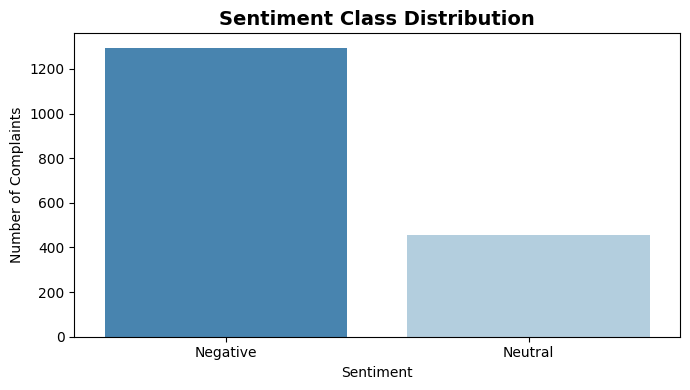

Sentiment_label
Negative    1295
Neutral      455
Name: count, dtype: int64


In [20]:
plt.figure(figsize=(7, 4))
labels = {0: 'Negative', 1: 'Neutral'}
df['Sentiment_label'] = df['Sentiment'].map(labels)

sns.countplot(x='Sentiment_label', data=df, palette='Blues_r',
              order=['Negative', 'Neutral'])
plt.title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.savefig('../models/eda_sentiment_distribution.png', dpi=150)
plt.show()
print(df['Sentiment_label'].value_counts())

C:\Users\onahe\AppData\Local\Temp\ipykernel_8780\868410463.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Priority_label', data=df, palette='Oranges_r',


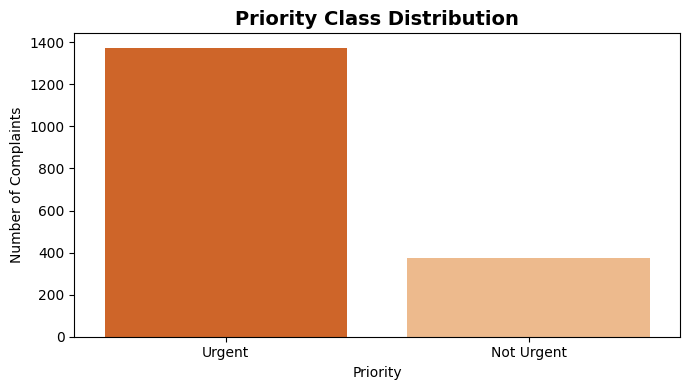

Priority_label
Urgent        1374
Not Urgent     376
Name: count, dtype: int64


In [21]:
plt.figure(figsize=(7, 4))
priority_labels = {0: 'Not Urgent', 1: 'Urgent'}
df['Priority_label'] = df['Priority'].map(priority_labels)

sns.countplot(x='Priority_label', data=df, palette='Oranges_r',
              order=['Urgent', 'Not Urgent'])
plt.title('Priority Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Priority')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.savefig('../models/eda_priority_distribution.png', dpi=150)
plt.show()
print(df['Priority_label'].value_counts())

<Figure size 1200x500 with 0 Axes>

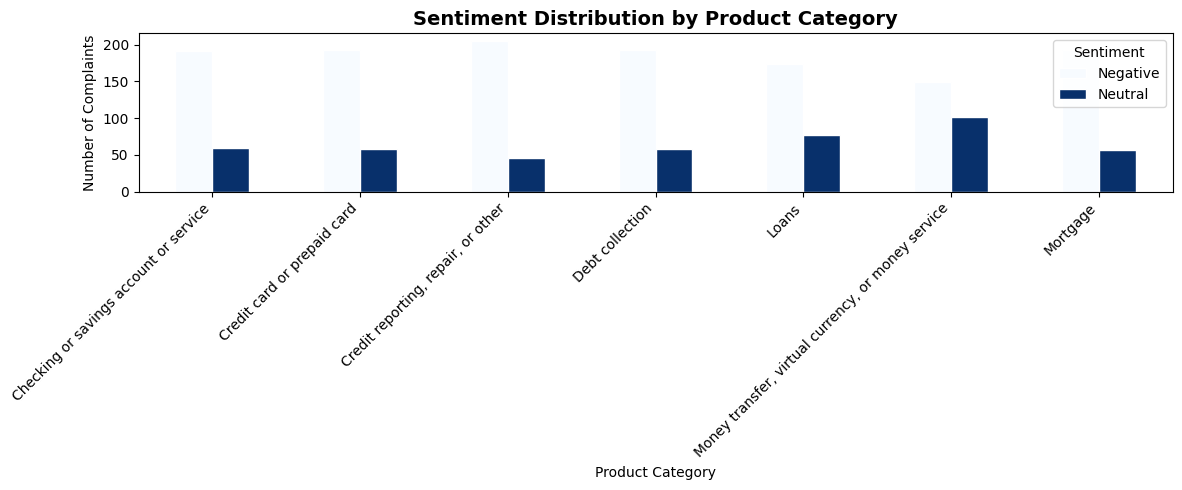

In [22]:
plt.figure(figsize=(12, 5))
ct = pd.crosstab(df['Product'], df['Sentiment_label'])
ct.plot(kind='bar', figsize=(12, 5), colormap='Blues', edgecolor='white')
plt.title('Sentiment Distribution by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('../models/eda_sentiment_by_product.png', dpi=150)
plt.show()

Text Length Statistics by Sentiment:
                  count        mean         std  min    25%    50%    75%  \
Sentiment_label                                                             
Negative         1295.0  241.525869  227.517706  2.0  100.0  178.0  308.0   
Neutral           455.0  137.340659  167.717327  7.0   45.5   91.0  170.5   

                    max  
Sentiment_label          
Negative         2618.0  
Neutral          2365.0  


C:\Users\onahe\AppData\Local\Temp\ipykernel_8780\2827051487.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment_label', y='text_length', data=df,


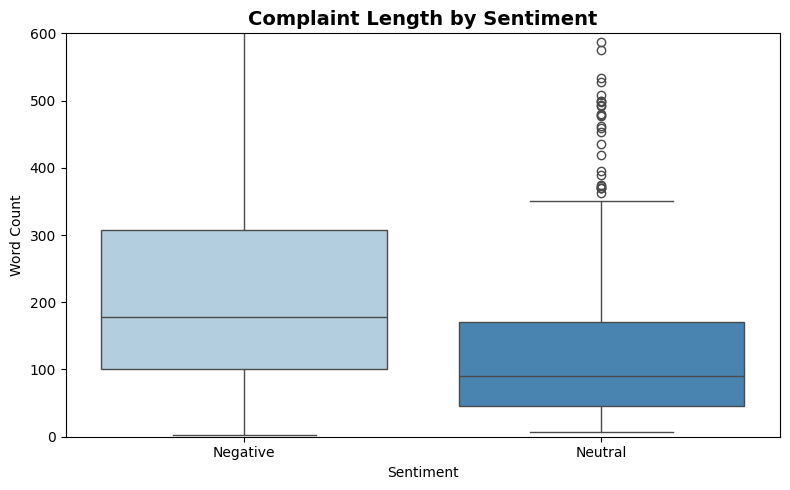

In [23]:
df['text_length'] = df['Consumer_complaint'].apply(lambda x: len(str(x).split()))

print("Text Length Statistics by Sentiment:")
print(df.groupby('Sentiment_label')['text_length'].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(x='Sentiment_label', y='text_length', data=df,
            palette='Blues', order=['Negative', 'Neutral'])
plt.title('Complaint Length by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.ylim(0, 600)
plt.tight_layout()
plt.savefig('../models/eda_length_by_sentiment.png', dpi=150)
plt.show()

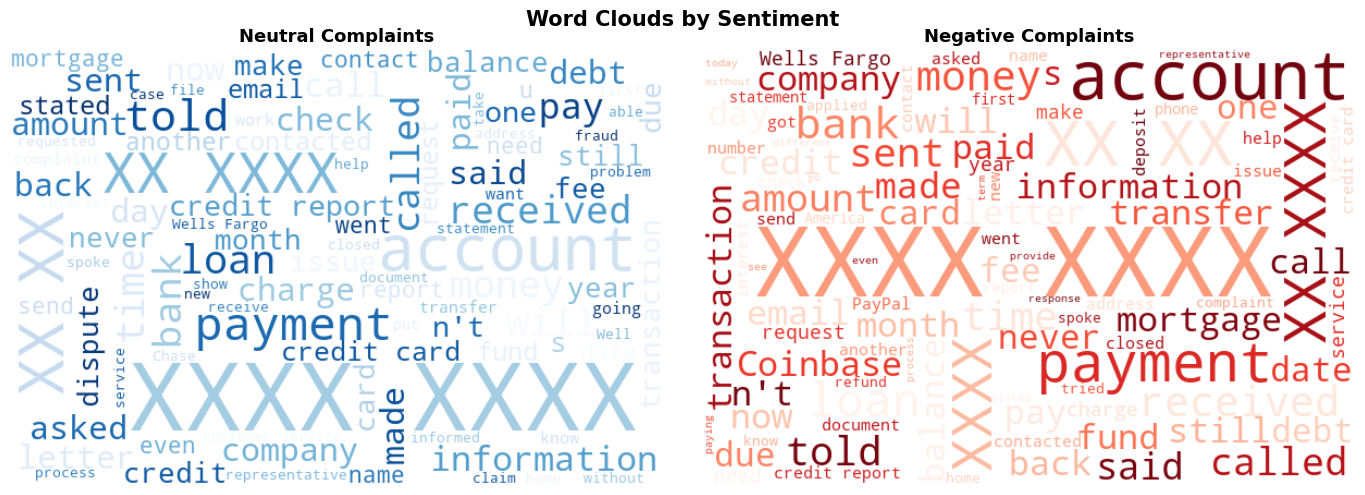

In [24]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (sentiment, label) in enumerate([(0, 'Neutral'), (1, 'Negative')]):
    text = ' '.join(df[df['Sentiment'] == sentiment]['Consumer_complaint'].dropna().astype(str).values)
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Blues' if sentiment == 0 else 'Reds',
        max_words=100
    ).generate(text)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{label} Complaints', fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_sentiment_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

print("Preprocessing text...")
df['clean_text'] = df['Consumer_complaint'].apply(preprocess)
print("Done.")
df[['Consumer_complaint', 'clean_text']].head(3)

Preprocessing text...
Done.


,Consumer_complaint,clean_text
0,I had overdraft protection with Regions Bank i...,overdraft protection region bank xxxx alabama ...
1,"I am the sole, legal representative of my dece...",sole legal representative deceased mother esta...
2,This bank has consistantly manipulated my dire...,bank consistantly manipulated direct deposit o...


In [26]:
X = df['clean_text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vectorization complete.")
print(f"Feature matrix shape: {X_train_tfidf.shape}")

Training samples: 1400
Testing samples:  350
Vectorization complete.
Feature matrix shape: (1400, 10000)


In [27]:
from sklearn.utils.class_weight import compute_class_weight

print("Training sentiment classifier with class balancing...")

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

model = LinearSVC(C=1.0, max_iter=2000, random_state=42, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

print("Training complete.")

Training sentiment classifier with class balancing...
Class weights: {np.int64(0): np.float64(0.6756756756756757), np.int64(1): np.float64(1.9230769230769231)}
Training complete.


Accuracy: 66.86 %

Classification Report:
              precision    recall  f1-score   support

Negative (1)       0.77      0.79      0.78       259
 Neutral (0)       0.35      0.32      0.33        91

    accuracy                           0.67       350
   macro avg       0.56      0.56      0.56       350
weighted avg       0.66      0.67      0.66       350



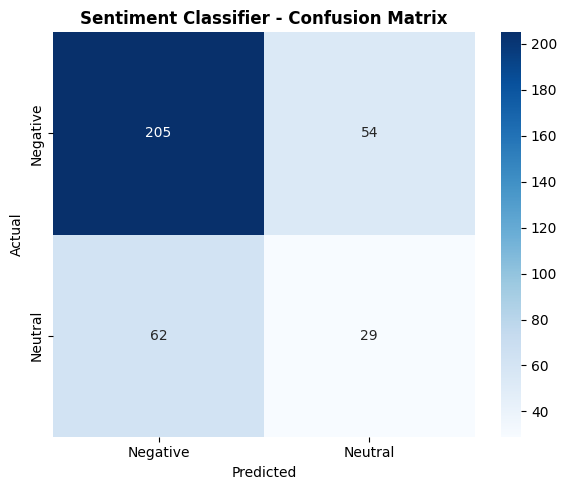

In [28]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative (1)', 'Neutral (0)']))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Negative', 'Neutral'],
            yticklabels=['Negative', 'Neutral'],
            cmap='Blues')
plt.title('Sentiment Classifier - Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../models/sentiment_confusion_matrix.png', dpi=150)
plt.show()

In [29]:
os.makedirs('../models', exist_ok=True)

joblib.dump(model, '../models/sentiment_model.pkl')
joblib.dump(vectorizer, '../models/sentiment_vectorizer.pkl')

print("sentiment_model.pkl saved successfully")
print("sentiment_vectorizer.pkl saved successfully")

sentiment_model.pkl saved successfully
sentiment_vectorizer.pkl saved successfully


In [33]:
import requests
import json

# ── Type your complaint here ──────────────────────────────────────────────
complaint = "I have been charged multiple times and no one is responding to my calls"
# ─────────────────────────────────────────────────────────────────────────

response = requests.post(
    'http://127.0.0.1:5000/predict',
    json={'complaint_text': complaint}
)

result = response.json()

print("=" * 60)
print("        COMPLAINTIQ — ML PREDICTION RESULT")
print("=" * 60)
print(f"  Complaint  : {result['complaint_text'][:80]}...")
print(f"  Category   : {result['category']}")
print(f"  Sentiment  : {result['sentiment']}")
print(f"  Priority   : {result['priority']}")
print("=" * 60)
print(f"  Sentiment Code : {result['sentiment_code']}")
print(f"  Priority Code  : {result['priority_code']}")
print("=" * 60)

        COMPLAINTIQ — ML PREDICTION RESULT
  Complaint  : I have been charged multiple times and no one is responding to my calls...
  Category   : Debt Collection
  Sentiment  : Negative
  Priority   : Urgent
  Sentiment Code : 0
  Priority Code  : 0
